[7.07036071e+03 3.35433013e+02 1.71455022e+02 1.15006757e+02
 8.64347973e+01 6.91786671e+01 5.76271277e+01 4.93526625e+01
 4.31339881e+01 3.82896200e+01 3.44093139e+01 3.12313314e+01
 2.85808188e+01 2.63365179e+01 2.44116924e+01 2.27426592e+01
 2.12816064e+01 1.99919390e+01 1.88451717e+01 1.78188006e+01
 1.68948110e+01 1.60586118e+01 1.52982587e+01 1.46038800e+01
 1.39672462e+01 1.33814415e+01 1.28406125e+01 1.23397709e+01
 1.18746401e+01 1.14415321e+01 1.10372501e+01 1.06590088e+01
 1.03043709e+01 9.97119363e+00 9.65758632e+00 9.36187392e+00
 9.08256724e+00 8.81833788e+00 8.56799709e+00 8.33047787e+00
 8.10481982e+00 7.89015610e+00 7.68570232e+00 7.49074700e+00
 7.30464324e+00 7.12680160e+00 6.95668382e+00 6.79379741e+00
 6.63769090e+00 6.48794959e+00 6.34419196e+00 6.20606637e+00
 6.07324821e+00 5.94543735e+00 5.82235585e+00 5.70374598e+00
 5.58936840e+00 5.47900056e+00 5.37243524e+00 5.26947925e+00
 5.16995227e+00 5.07368581e+00 4.98052221e+00 4.89031385e+00
 4.80292231e+00 4.718217

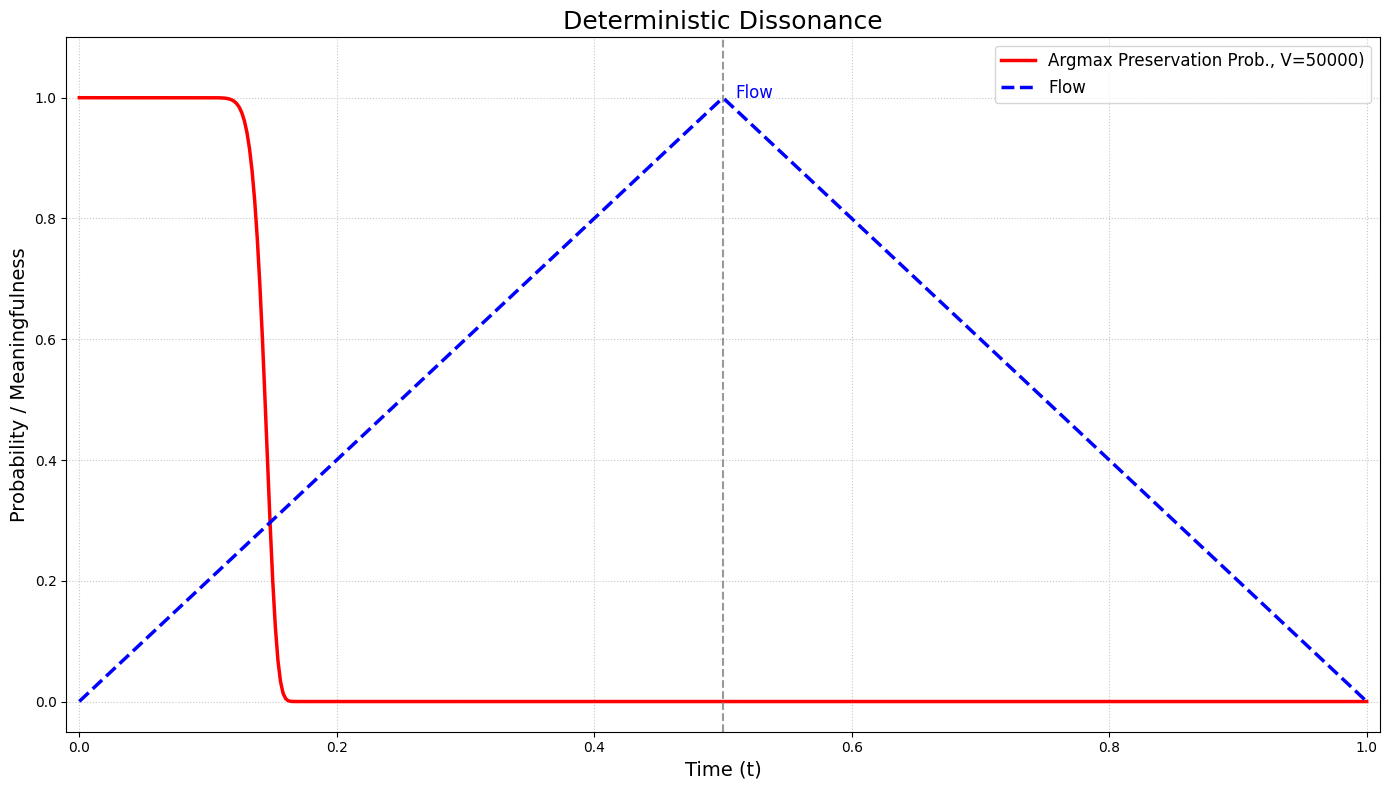

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings

# Ignore warnings (e.g., log(0))
warnings.filterwarnings('ignore')

# --- 1. Parameters ---
V = 50000  # Vocabulary size (e.g., 50,000)
t = np.linspace(0.0001, 0.9999, 500) # Time t (excluding 0 and 1)

# --- 2. Calculate "Structure" Curve (Argmax Preservation Prob.) ---
# P(argmax preserved) = [P(Z < (1-t)/t)]^(V-1), where Z ~ N(0, 2)
# We use log-probability for numerical stability

# C(t) = (1-t) / t
C_t = (1 - t) / t

# log(p(t)) = log(P(Z < C(t)))
# Since Z ~ N(0, 2), Z/sqrt(2) ~ N(0, 1)
# log_p_t = norm.logcdf(C_t / np.sqrt(2))
print(C_t/np.sqrt(2))
log_p_t = norm.logcdf(C_t / np.sqrt(2))

# log(P(argmax preserved)) = (V - 1) * log(p(t))
log_structure_prob = (V - 1) * log_p_t

# P(argmax preserved)
structure_prob = np.exp(log_structure_prob)

# --- 3. Calculate "Flow" Curve (Learning Meaningfulness) ---
# Using 2*min(t, 1-t) as a proxy for how "well-posed" the
# vector field learning task is, which peaks at t=0.5
flow_well_posedness = 2 * np.minimum(t, 1 - t)

# --- 4. Plotting ---
plt.figure(figsize=(14, 8))

# "Structure" Curve
plt.plot(t, structure_prob, 'r-', 
         label=f'Argmax Preservation Prob., V={V})', linewidth=2.5)

# "Flow" Curve
plt.plot(t, flow_well_posedness, 'b--', 
         label='Flow', linewidth=2.5)

# --- 5. Style Plot ---
plt.title('Deterministic Dissonance', fontsize=18)
plt.xlabel('Time (t)', fontsize=14)
plt.ylabel('Probability / Meaningfulness', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim([-0.05, 1.1])
plt.xlim([-0.01, 1.01])

# Mark t=0.5 point
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.8)
plt.text(0.51, 1.0, 'Flow', 
         color='blue', ha='left', fontsize=12)

         
# Mark region near t=0
# plt.text(0.1, 1.0, '"Structure" Preservation Zone', color='red', ha='left', fontsize=12)
# plt.text(0.1, 0.3, '"Flow" Learning Impossible Zone\n(ill-posed)', color='blue', ha='left', fontsize=12)

plt.tight_layout()
plt.savefig('deterministic_dissonance_plot.png')
print("Graph saved to 'deterministic_dissonance_plot.png'.")

# Uncomment the line below if you are running this in a local environment
# and want the plot to pop up.
# plt.show()

In [6]:
gamma_min = -3.75
gamma_max = -1.5
t= 0.5
gamma_t = gamma_min + t * (gamma_max- gamma_min)    
gamma_t

-2.625